In [1]:
import torch 
import torch.nn as nn

In [2]:
import numpy as np

In [3]:
from basemodel import *

In [4]:
from data_handler import *

In [5]:
from optimizer import *
from scheduler import *

In [6]:
from fit import *

In [7]:
import matplotlib.pyplot as plt

In [8]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [9]:
import cbs

In [10]:
from unet import Unet_sigmoid

In [11]:
from collections import OrderedDict

In [12]:
import random

In [13]:
import unet_ein as ue

In [14]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

In [15]:
from torch.distributions import normal

In [16]:
import pytorch_ssim

# Data

In [17]:
trn_ , val_ = split('../dataset/fuz attack/generated_ds/train/',prc = 0.01, dataset_pct=  1, dim =(1), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/generated_ds/test/',prc = 0 , dataset_pct=  1, dim = (1), word_type=torch.float)

In [272]:
bs = 1
seq_len = 8
overlap=0

In [273]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[1])
v4_val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[1])

In [274]:
v4_anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[1])

In [275]:
dl =CombineDataLoader(trn_dl,v4_val_dl)

In [248]:

len(trn_dl)

797

In [237]:
len(trn_dl)

6377

In [249]:
6377/797

8.00125470514429

# Custom Loss

In [22]:
class SSIM:
    def __init__(self):
        self.ssim_loss = pytorch_ssim.SSIM(window_size = 11)
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka= ip
        tgt_lka = tgt_lka [None,None,None,:]
        ip_lka = ip_lka [None,None,None,:]
        
        lka = self.ssim_loss(ip_lka,tgt_lka)
        return 1-(lka)

In [385]:
class binary:
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka = ip
        
        #vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
        #lka = nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        lka = nn.functional.binary_cross_entropy(ip_lka,tgt_lka)
        return lka

In [396]:
class mse:
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka = ip
        
        #vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
        #lka = nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        lka = nn.functional.mse_loss(ip_lka,tgt_lka)
        return lka

In [397]:
loss = binary()

## Helping methods

In [25]:
def get_vis(frame):
    binary_value = torch.cat((frame[-4:],frame[:8]))
    new_frame = frame.type(torch.int).tolist()
    new_frame = [str(i) for i in new_frame]
    s = ''.join(new_frame)
    binary_value_str = s[-4:] + s[:8]
    
    return binary_value,torch.tensor([max(0.0,(int(binary_value_str,2) *0.01)-16)])

In [26]:
def normalize(value):
    return torch.abs(value / 4).cuda()

In [27]:
def diff_avg(l,window):
    l = torch.tensor(l)
    if len(l) < window and len(l)>1:
        return l.std()
    elif len(l)>window:
        return l[-window:].std()
    return torch.zeros(1)

# Model : Predective toggle lka

In [ ]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
       
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = [0]*80
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        
        self.rep = nn.Sequential(nn.Linear(64,4),
                                nn.PReLU(),
                                nn.Dropout(0.5),
                                nn.Linear(4,10),
                                nn.Sigmoid())
        self.art_lka =[]
        self.values = []
        self.lstm = nn.Sequential(nn.Dropout(0.5),
                                  nn.LSTM(2,64,1,dropout=0.5))
        
        self.lstm_out = nn.Sequential(nn.Dropout(0.5),
                                  nn.LSTM(64,1,1,dropout=0.5))
        self.once =0
        
    
    def forward(self,x):
        self.c += 1
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
            self.c=0
        if self.c == 1:
            if self.once == 0:
                print('teet')
                #self.vis_values.extend( x.view(-1).detach().cpu().numpy())
                self.once=1
        
        if self.c == 1 and self.training:        
            self.art_lka =[]
            print('in')
            idx = random.randint(0,5)
            if idx  != 0:
                self.art_lka.extend( torch.randint(0,170,(1,(idx))).tolist()[0])
            
            if idx%2 ==0:
                print('odd')
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(290,350,(1,((idx*2)+1))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(290,350,(1,((idx*2)))).tolist()[0])
                          
            idx = random.randint(0,3)
            if idx  != 0:
                self.art_lka.extend( torch.randint(570,620,(1,(idx))).tolist()[0])
            
            
            if idx%2 ==0:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(705,730,(1,((idx*2)))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(705,730,(1,((idx*2)+1))).tolist()[0])
                
            print(self.art_lka)
        elif self.c == 1 and not self.training:
            self.art_lka = [20,70,100,250,350,450]
        if  self.c in self.art_lka :

            if self.lka[0]:
                print('LKA OFF',self.c)
                self.lka = torch.zeros(1).cuda()
            else:
                print('LKA ON',self.c)
                self.lka = torch.ones(1).cuda()
        
        self.vis = x.view(-1)[-1]
        
        l = torch.tensor(self.lka_values[-50:-10]).type(torch.float).cuda()
        v = torch.tensor(x.view(-1)[-42:-2]).cuda()
        
        stack = torch.stack([v,v]).view(40,1,2)
        
        op = self.lstm(stack)
        seq = op[-1][0]
        predected_lka = nn.functional.sigmoid(self.lstm_out(seq.expand(2,1,64))[0])
        
        #predected_lka = self.rep(op[-1][0])
        
        
        self.vis_values.append( x.view(-1).detach().cpu().numpy()[-1])
        self.lka_values.append(self.lka)
        self.values.append([self.lka,self.vis,predected_lka.view(-1)[-10:]])
        
        return torch.tensor(self.lka_values[-2:]).view(-1).cuda(),predected_lka.view(-1)[-2:]


In [28]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
       
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = [0]*80
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        
        self.rep = nn.Sequential(nn.Linear(64,4),
                                    nn.PReLU(),
                                    nn.Dropout(0.5),
                                    nn.Linear(4,10),
                                    nn.Sigmoid())
        self.art_lka =[]
        self.values = []
        self.lstm = nn.LSTM(2,64,2,dropout=0.5)
        self.once =0
        
    
    def forward(self,x):
        self.c += 1
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
            self.c=0
        if self.c == 1:
            if self.once == 0:
                print('teet')
                #self.vis_values.extend( x.view(-1).detach().cpu().numpy())
                self.once=1
        
        if self.c == 1 and self.training:        
            self.art_lka =[]
            print('in')
            idx = random.randint(0,5)
            if idx  != 0:
                self.art_lka.extend( torch.randint(0,170,(1,(idx))).tolist()[0])
            
            if idx%2 ==0:
                print('odd')
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(290,350,(1,((idx*2)+1))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(290,350,(1,((idx*2)))).tolist()[0])
                          
            idx = random.randint(0,3)
            if idx  != 0:
                self.art_lka.extend( torch.randint(570,620,(1,(idx))).tolist()[0])
            
            
            if idx%2 ==0:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(705,730,(1,((idx*2)))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(705,730,(1,((idx*2)+1))).tolist()[0])
                
            print(self.art_lka)
        elif self.c == 1 and not self.training:
            self.art_lka = [20,70,100,250,350,450]
        if  self.c in self.art_lka :

            if self.lka[0]:
                print('LKA OFF',self.c)
                self.lka = torch.zeros(1).cuda()
            else:
                print('LKA ON',self.c)
                self.lka = torch.ones(1).cuda()
        
        self.vis = x.view(-1)[-1]
        
        l = torch.tensor(self.lka_values[-50:-10]).type(torch.float).cuda()
        v = torch.tensor(x.view(-1).detach().cpu().numpy()[-50:-10]).cuda()
        
        stack = torch.stack([l*v,v]).view(40,1,2)
        
        op = self.lstm(stack)
        
        predected_lka = self.rep(op[-1][-1])
        
        
        self.vis_values.append( x.view(-1).detach().cpu().numpy()[-1])
        self.lka_values.append(self.lka.detach())
        self.values.append([self.lka,self.vis,predected_lka])
        
        return torch.tensor(self.lka_values[-10:]).view(-1).cuda(),predected_lka.view(-1)[-10:]


In [50]:
m =  unet_seq(bs,seq_len).cuda()

In [51]:
opt = torch.optim.Adam(m.parameters(),1e-2)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [52]:
trn_item = Validate(trn_dl)

In [53]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [54]:
#cbs.load_all('documentation/lka/lstm/1/', model=m , learn=learn,opt=opt, sched = sched)

In [55]:
m.max_count = len(trn_dl)+len(v4_val_dl)

In [56]:
loss = custom()

In [57]:
m.lka = torch.zeros(1).cuda()

In [58]:
learn.fit(m , opt , 2 , dl,loss  ,callbacks=[sched])

teet
in
odd
[326, 582, 610, 617, 711, 721, 720]


RuntimeError: invalid argument 0: Tensors must have same number of dimensions: got 1 and 3 at /pytorch/aten/src/THC/generic/THCTensorMath.cu:62

In [56]:
lka = [i[0] for i in m.values]
vis = [i[1] for i in m.values]
op = [i[2].view(-1)[:10][0] for i in m.values]

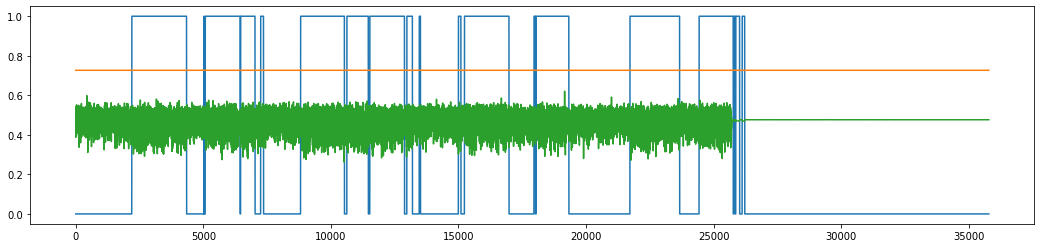

In [57]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
ax.plot(range(len(op)),op)

In [377]:
m.c

0

In [62]:
m.lka =torch.zeros(1).cuda()
m.c =0
m.max_count = len(v4_anml_dl)
m.values = []

In [63]:
v4_anml_item.evaluate(model = m , crit = loss)

  3%|▎         | 106/3576 [00:00<00:03, 1053.13it/s]

testing...


 98%|█████████▊| 3517/3576 [00:02<00:00, 1251.08it/s]

In [64]:
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 

In [65]:
lka = [i[0] for i in m.values]
vis = [i[1] for i in m.values]
#diff = [i[0][3] for i in m.lka_values]
#op = [i[1][0] for i in m.values]

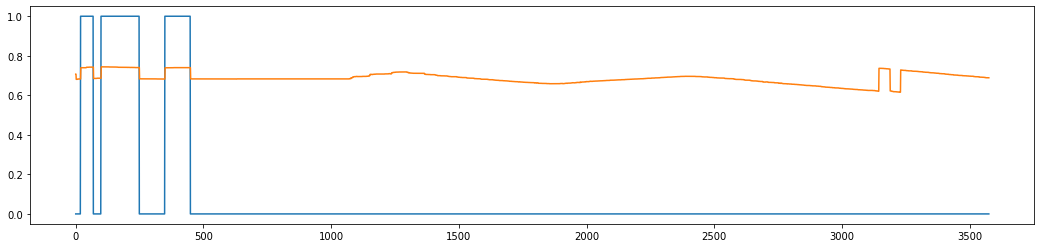

In [69]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
#ax.plot(range(len(vis)),vis)
ax.plot(range(len(b)),list(b))

In [363]:
b[62],b[405]

(tensor(0.2250), tensor(0.2248))

In [364]:
b[24:64].max(),b[355:444].max()

(tensor(0.8059), tensor(0.6174))

In [345]:
path = 'Models/documentation/lka/lstm/1/'
#save(path,[a,b,c],names=['normal','attack','train'])

In [597]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)

# Model :LSTM

In [124]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(2,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,8),
                                            nn.PReLU(),
                                            nn.Dropout(0.25),
                                            nn.Linear(8,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.25),
                                            nn.Linear(16,2),
                                            nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c = 0
        
        self.vis_values = torch.tensor(np.random.normal(1.6737,0.3800,50)).tolist()
        self.vis_idx = []
        
        self.lka_values = [0]*50
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        
        self.rep = nn.Sequential(nn.Linear(64,32),
                                    nn.PReLU(),
                                    nn.Dropout(0.25),
                                    nn.Linear(32,5),
                                    nn.Sigmoid())
        self.art_lka =[]
        self.values = []
        self.lstm = nn.LSTM(2,64,2,dropout=0.8)
    def forward(self,x):   
        self.c = (self.c+1) % self.max_count
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
        
        if self.c == 1 :
            self.vis_values = torch.tensor(np.random.normal(1.6737,0.3800,50)).tolist()
            self.art_lka =[]
            print('in')
            idx = random.randint(0,50)
            if idx  != 0:
                self.art_lka = torch.randint(0,500,(1,(idx*2))).tolist()[0]
            print(self.art_lka)
            
        if   self.c in [10,20,30] :
            #[1000,1300]
            #[2400]
            #[10,20,30,2400]
            #[20,30,50,2400]
            #[10,20,30]
            #lka_idx.size or self.c in self.art_lka
            #[0,20,30,35,45,48,50,60,68,70,75,80,95,100,150,180,230,250,300,320,333,350,390,400,480]
            ## Exception
            #if self.c in [2399,2400]:
            #    pass
            if self.lka[0]:
                print('LKA OFF',self.c)
                self.lka = torch.zeros(1).cuda()
            else:
                print('LKA ON',self.c)
                self.lka = torch.ones(1).cuda()
        
        #history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        #diff_mean = diff_avg(self.vis_values,100)
        
        #past_rep
        
        #past_rep = self.rep((torch.tensor(self.vis_values[-50:]).cuda()+self.lka) * normalize(self.vis))
        
        #left_lane = torch.tensor(4-self.vis-0.5).cuda()
        #previous_left_lane = torch.tensor(4-self.previous_vis-0.5).cuda()
        cat=torch.cat([self.lka,normalize(self.vis)])#.cuda()
        l = torch.tensor(self.lka_values[-50:-5]).type(torch.float).cuda()
        v = torch.tensor(self.vis_values[-50:-5]).cuda()
        
        stack = torch.stack([l,v]).view(45,1,2)
        
        op = self.lstm(stack)
        
        predected_lka = self.rep(op[-1][-1])
        #predected_lka = self.lka_compressor(cat*past_rep)
        
        self.previous_vis = self.vis.data.detach()
        self.previous_lka = self.lka.data.detach()
        #self.previous_states = history.data.detach()
        
        self.lka_values.append(self.lka.detach())
        self.values.append(cat)
        
        return torch.tensor(self.lka_values[-5:]).view(-1).cuda(),predected_lka.view(-1)[:5]


In [125]:
m =  unet_seq(bs,seq_len).cuda()

In [126]:
opt = torch.optim.Adam(m.parameters(),1e-12)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [127]:
trn_item = Validate(trn_dl)

In [128]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [129]:
cbs.load_all('documentation/lka/lstm/1/', model=m , learn=learn,opt=opt, sched = sched)

In [130]:
m.max_count = 2352

In [131]:
loss = custom()

In [132]:
#learn.fit(m , opt , 8 , dl,loss  ,callbacks=[sched])

In [133]:
len(trn_dl)+len(v4_val_dl)+len(v4_anml_dl)

3575

In [134]:
m.lka =torch.zeros(1).cuda()
#m.vis_values = []
m.c =0
m.max_count = 3576
m.values = []

In [135]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 8/2326 [00:00<00:29, 79.57it/s]

testing...
in
[199, 229, 196, 479, 231, 202, 316, 36, 313, 6, 49, 235, 13, 124, 49, 196, 449, 133, 427, 497]
LKA ON 10
LKA OFF 20


  2%|▏         | 49/2326 [00:00<00:21, 107.15it/s]

LKA ON 30


100%|█████████▉| 2325/2326 [00:18<00:00, 129.08it/s]

In [136]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

 24%|██▍       | 6/25 [00:00<00:00, 57.42it/s]

testing...


  1%|          | 9/1224 [00:00<00:14, 82.52it/s]

testing...


 99%|█████████▉| 1213/1224 [00:09<00:00, 132.09it/s]

In [137]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [138]:
max(b[0:100]),max(c[2:500])

(tensor(0.2455), tensor(0.2616))

In [139]:
lka = [i[0] for i in m.values]
vis = [i[1] for i in m.values]
#diff = [i[0][3] for i in m.lka_values]
#op = [i[1][0] for i in m.values]

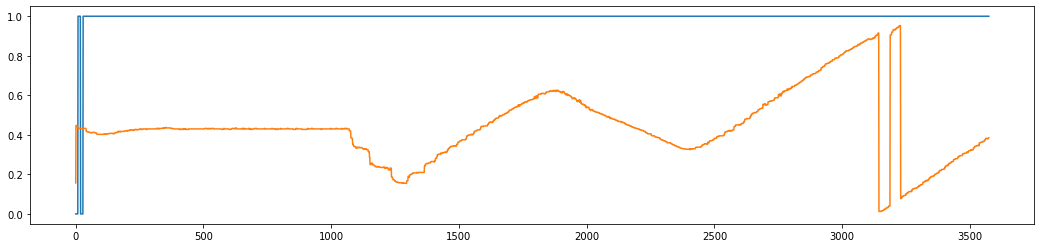

In [140]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
#ax.plot(range(len(op)),op)


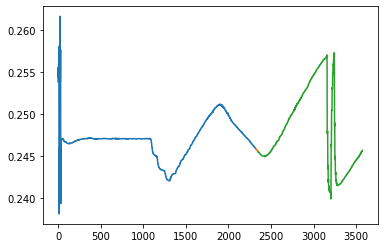

In [141]:
threshold = b[:100].max()
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))
ax.plot(range(len(c),len(c)+len(a)),list(a))
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b))
#ax.plot(range(len(lka)),lka)
#ax.plot(range(len(a)+len(b)+len(c)), [threshold]*(len(a)+len(b)+len(c)))

In [57]:
path = 'Models/documentation/lka/lstm/1/'
#save(path,[a,b,c],names=['normal','attack','train'])

In [597]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)

# Model : Predective toggle vis

In [38]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(12*1,6),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(6,12))
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros(12).cuda()
        self.previous_vis = torch.zeros(12).cuda()
        self.previous_states = torch.zeros(12).cuda()
        
        self.c = 0
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = []
        self.Unify = nn.Linear(24,12)
    def forward(self,x):   
        self.c +=1
        input_list = x.view(160,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(160,-1)[vis_idx[0]][120:208]
            self.vis,vis_value = get_vis(frame[28:28+16].data)
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*160)
        if lka_idx.size or self.c in [50,200]:
            print(self.c)
            if self.lka[0]: 
                self.lka = torch.zeros(1).cuda()
            else:
                print('yes')
                self.lka = torch.ones(1).cuda()
            
            
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        #predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka.expand(12)])))
        predected_lka = torch.sigmoid(self.Unify(torch.cat([self.previous_lka.expand(12),history])))
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        self.previous_lka = self.lka.detach().cuda()
        
        self.lka_values.append([self.lka.data,predected_lka.data])
        return self.vis,predected_lka


Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f46003e5e10>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
    w.join()
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/process.py", line 124, in join
    res = self._popen.wait(timeout)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 50, in wait
    return self.poll(os.WNOHANG if timeout == 0.0 else 0)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 28, in poll
    pid, sts = os.waitpid(self.pid, flag)
KeyboardInterrupt: 


In [320]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(2,64),
                                            nn.PReLU(),
                                            nn.Dropout(0.0),
                                            nn.Linear(64,2))
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = 0
        self.previous_vis = 0
        self.previous_states = torch.zeros(12).cuda()
        
        self.c = 0
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = []
        self.Unify = nn.Linear(2,1)
    def forward(self,x):   
        self.c +=1
        input_list = x.view(160,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(160,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*160)
        if lka_idx.size or self.c in [50,210]:
            print(self.c)
            if self.lka[0]: 
                self.lka = torch.zeros(1).cuda()
            else:
                print('yes')
                self.lka = torch.ones(1).cuda()
            
            
        #Get the history of vis from previous vis and all the past frames
        #history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        #history = self.drop(nn.functional.relu(history))
        #predected_lka = self.lka_compressor(torch.cat([self.previous_lka.expand(12)]))
        a1 = torch.tensor([self.previous_lka])
        a2 = torch.tensor([self.previous_vis]) 
        a=torch.cat([a1,a2]).type(torch.float).cuda()
        predected_lka = torch.sigmoid(self.lka_compressor(a))
        
        self.previous_vis = self.vis#.detach().data
        #self.previous_states = history.detach().data
        self.previous_lka = self.lka#.detach().data()
        
        self.lka_values.append([a,predected_lka.data])
        return normalize(torch.tensor(self.vis)).cuda(),predected_lka


In [39]:
m =  unet_seq(bs,seq_len).cuda()

In [40]:
opt = torch.optim.Adam(m.parameters(),1e-6)
opt = BaseOptimizer(opt)
learn = learner()

In [41]:
trn_item = Validate(trn_dl)

In [42]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [43]:
m.lka = torch.zeros_like(m.lka).cuda()

In [44]:
path = 'documentation/lka/lka given binary vis/1/bin/'
cbs.load_all(path,model = m,learn=learn,opt=opt )

RuntimeError: Error(s) in loading state_dict for unet_seq:
	size mismatch for lka_compressor.0.weight: copying a param with shape torch.Size([32, 2]) from checkpoint, the shape in current model is torch.Size([6, 12]).
	size mismatch for lka_compressor.0.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([6]).
	size mismatch for lka_compressor.3.weight: copying a param with shape torch.Size([2, 32]) from checkpoint, the shape in current model is torch.Size([12, 6]).
	size mismatch for lka_compressor.3.bias: copying a param with shape torch.Size([2]) from checkpoint, the shape in current model is torch.Size([12]).
	size mismatch for Unify.weight: copying a param with shape torch.Size([1, 2]) from checkpoint, the shape in current model is torch.Size([12, 24]).
	size mismatch for Unify.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([12]).

In [45]:
learn.fit(m , opt , 1 , dl,loss  )

  3%|▎         | 66/2060 [00:00<00:17, 112.70it/s, loss : 0.49235199436996924]

50
yes


 11%|█         | 221/2060 [00:01<00:13, 137.07it/s, loss : 0.49095971983482395]

200


 27%|██▋       | 558/2060 [00:04<00:27, 55.41it/s, loss : 0.5049710837743615]  

KeyboardInterrupt: 

In [309]:
m.lka = torch.zeros_like(m.lka).cuda()

In [310]:
m.c = 1
m.vis_idx = []
m.vis_values = []

In [311]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 0/1023 [00:00<?, ?it/s]

testing...


/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  import sys
  6%|▌         | 57/1023 [00:00<00:15, 63.58it/s]

50
yes


 21%|██        | 217/1023 [00:03<00:11, 73.14it/s]

210


 37%|███▋      | 377/1023 [00:05<00:08, 72.75it/s]

370
yes


100%|██████████| 1023/1023 [00:14<00:00, 73.71it/s]

In [312]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 0/255 [00:00<?, ?it/s]/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  import sys
  2%|▏         | 4/255 [00:00<00:06, 38.37it/s]

testing...


  1%|          | 5/608 [00:00<00:15, 39.86it/s]s]

testing...


  5%|▍         | 29/608 [00:00<00:10, 54.70it/s]

1303


100%|█████████▉| 605/608 [00:08<00:00, 73.43it/s]

In [313]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

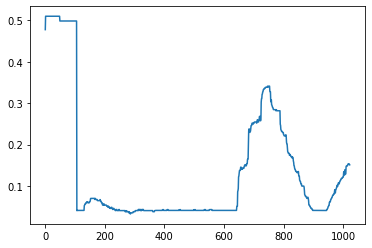

In [314]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))

In [315]:
max(c[190:210])

tensor(0.0595)

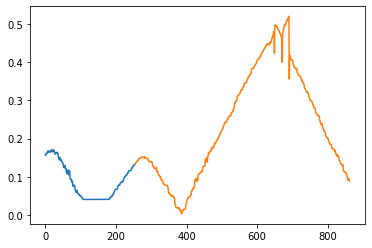

In [316]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))
#ax.plot(range(len(a)+len(b)), [a.max()+ a.max()*0.2]*(len(a)+len(b)))

In [317]:
max(b[:500])

tensor(0.5194)

In [262]:
m.lka_values[0:]

[[tensor([0., 0.], device='cuda:0'),
  tensor([0.5449, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [tensor([0., 0.], device='cuda:0'),
  tensor([0.5448, 0.5811], device='cuda:0')],
 [te

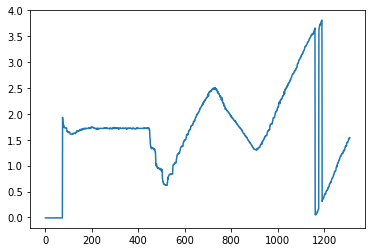

In [218]:
fig,ax = plt.subplots()
ax.plot(range(len(m.vis_values)),m.vis_values)


In [106]:
path = 'Models/documentation/lka/lka given binary vis/1/bin/'

In [107]:
cbs.save_all(path,model=m,learn=learn,opt=opt)

## AE

In [298]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
       
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = [0]*80
        self.max_count = 2352
        self.previous_lka = torch.zeros(1).cuda()
        self.diff_avg = []
        #list of artficial lka 
        

        self.art_lka =[]
        self.values = []
        
        self.lka_compressor = nn.Sequential(nn.Linear(3,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,4),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(4,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,3),
                                            nn.Sigmoid())
        
       
        self.once =0
        
    
    def forward(self,x):
        self.c += 1
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
            self.c=0
        if self.c == 1:
            if self.once == 0:
                print('teet')
                #self.vis_values.extend( x.view(-1).detach().cpu().numpy())
                self.once=1
        
        if self.c == 1 and self.training:        
            self.art_lka =[]
            print('in')
            idx = random.randint(0,5)
            if idx  != 0:
                self.art_lka.extend( torch.randint(0,170,(1,(idx))).tolist()[0])
            
            if idx%2 ==0:
                print('odd')
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(290,350,(1,((idx*2)+1))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(290,350,(1,((idx*2)))).tolist()[0])
                          
            idx = random.randint(0,3)
            if idx  != 0:
                self.art_lka.extend( torch.randint(570,620,(1,(idx))).tolist()[0])
            
            
            if idx%2 ==0:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(705,730,(1,((idx*2)))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(705,730,(1,((idx*2)+1))).tolist()[0])
                
            print(self.art_lka)
        elif self.c == 1 and self.eval:
            self.art_lka = [20,70,100,250,350]
        if  self.c in self.art_lka :

            if self.lka[0]:
                print('LKA OFF',self.c)
                self.lka = torch.zeros(1).cuda()
            else:
                print('LKA ON',self.c)
                self.lka = torch.ones(1).cuda()
        
        self.vis = torch.tensor(x.view(-1)[-1]).view(1)
        

        v = torch.tensor(x.view(-1).detach().cpu().numpy()[-50:-10]).cuda()
        ######
        cat=torch.cat([self.previous_lka,self.vis,diff_avg(self.vis_values,10).view(1).cuda()])#.cuda()
        
        predected_lka = self.lka_compressor(cat)

        #########
        
        
        self.vis_values.append( x.view(-1).detach().cpu().numpy()[-1])
        self.lka_values.append(self.lka.detach())
        self.previous_lka = self.lka.detach()
        self.values.append([self.lka,self.vis])
        
        return cat[0:1],predected_lka[0:1]


Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7fe495d0c048>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
    w.join()
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/process.py", line 124, in join
    res = self._popen.wait(timeout)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 50, in wait
    return self.poll(os.WNOHANG if timeout == 0.0 else 0)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 28, in poll
    pid, sts = os.waitpid(self.pid, flag)
KeyboardInterrupt: 


In [299]:
m =  unet_seq(bs,seq_len).cuda()

In [300]:
opt = torch.optim.Adam(m.parameters(),1e-2)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [301]:
trn_item = Validate(trn_dl)

In [302]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [303]:
#cbs.load_all('documentation/lka/lstm/1/', model=m , learn=learn,opt=opt, sched = sched)

In [304]:
m.max_count = len(trn_dl)+len(v4_val_dl)

In [305]:
loss = custom()

In [306]:
m.lka = torch.zeros(1).cuda()

In [307]:
learn.fit(m , opt , 4 , dl,loss  ,callbacks=[sched])

/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  4%|▎         | 33/909 [00:00<00:05, 149.12it/s, loss : 0.3562784483938506]

teet
in
[60, 722, 713]


 10%|█         | 93/909 [00:00<00:04, 172.40it/s, loss : 0.9391352335611979]

LKA ON 60


 81%|████████  | 733/909 [00:03<00:00, 189.82it/s, loss : 0.3095563651757546] 

...

LKA OFF 617


 83%|████████▎ | 751/909 [00:04<00:00, 188.14it/s, loss : 0.07015028139563914]

LKA ON 716
LKA OFF 721
LKA ON 724


                                              t/s, loss : 0.06394890422371502]

train Loss:  0.06408755481243134   validation loss:  0.0
tensor(nan)


In [308]:
lka = [i[0] for i in m.values]
vis = [i[1] for i in m.values]

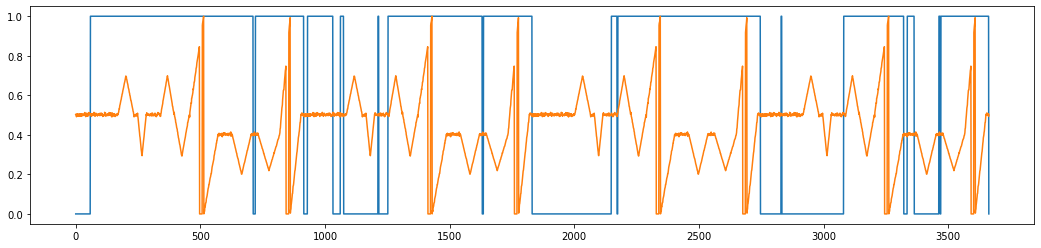

In [309]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)


In [310]:
m.c

0

In [311]:
m.lka =torch.zeros(1).cuda()
m.c =0
m.max_count = len(v4_anml_dl)
m.values = []

In [312]:
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 0/509 [00:00<?, ?it/s]

testing...


Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7fe49572d278>>
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7fe49572d278>>
Traceback (most recent call last):
Traceback (most recent call last):
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7fe49572d278>>
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7fe49572d278>>
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
Traceback (most recent call last):
Traceback (most recen

LKA ON 20


 13%|█▎        | 68/509 [00:00<00:28, 15.24it/s]

...

 53%|█████▎    | 272/509 [00:01<00:01, 142.97it/s]

LKA OFF 250


 73%|███████▎  | 372/509 [00:02<00:00, 184.17it/s]

LKA ON 350


 97%|█████████▋| 492/509 [00:02<00:00, 195.17it/s]

In [313]:
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 

In [314]:
lka = [i[0] for i in m.values]
vis = [i[1] for i in m.values]
#diff = [i[0][3] for i in m.lka_values]
#op = [i[1][0] for i in m.values]

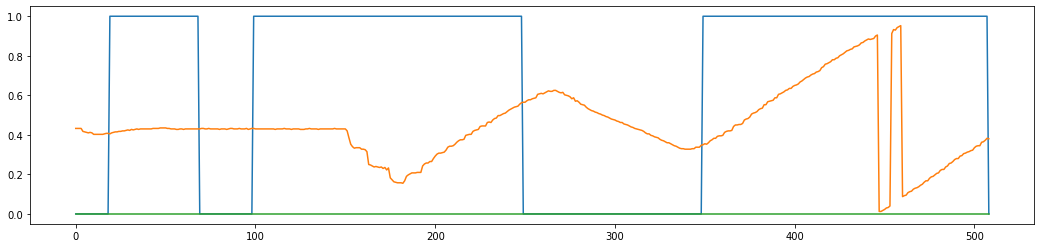

In [316]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
ax.plot(range(len(b)),list(b))

In [649]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        self.lka_compressor = nn.Sequential(nn.Linear(8,64),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(64,4),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(4,64),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(64,1),
                                            nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = []
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        self.art_lka =[]
        self.values = []
        self.lstm = nn.LSTM(2,64,2,dropout=0.5)
        self.once =0
        
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = False
        self.max_count= 2352
        
    def forward(self,x):
        
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
            self.c=0
        if self.c == 0:
            if self.once == 0:
                print('teet')
                #self.vis_values.extend( x.view(-1).detach().cpu().numpy())
                self.once=1
        
        if self.c == 0 and not self.test:        
            self.art_lka =[]
            print('in')
            idx = random.randint(0,5)
            if idx  != 0:
                self.art_lka.extend( torch.randint(0,1000,(1,(idx))).tolist()[0])
            
            if idx%2 ==0:
                print('odd')
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(2000,2400,(1,((idx*2)+1))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(2000,2400,(1,((idx*2)))).tolist()[0])
                          
            idx = random.randint(0,3)
            if idx  != 0:
                self.art_lka.extend( torch.randint(4000,4400,(1,(idx))).tolist()[0])
            
            
            if idx%2 ==0:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(5000,5200,(1,((idx*2)))).tolist()[0])
            else:
                idx = random.randint(0,1) 
                self.art_lka.extend( torch.randint(5000,5200,(1,((idx*2)+1))).tolist()[0])
            self.art_lka = torch.tensor(self.art_lka) // 7
            self.art_lka = list(torch.tensor(self.art_lka).numpy())
            print(self.art_lka)
        
        if self.c in self.art_lka :
            print('Pulse')
            self.lka =torch.logical_xor(m.lka.type(torch.BoolTensor),torch.ones_like(m.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()
            
        
        cat=torch.cat([x.view(-1)])#.cuda()
        predected_lka = self.lka_compressor(cat)
        
        self.previous_vis = self.vis.data
        self.previous_lka = self.lka.data
        
        self.vis_values.append( x.view(-1).detach().cpu().numpy()[-1])
        self.lka_values.append(self.lka.detach())
        self.values.append([self.lka,self.vis,predected_lka])
        
        self.flag_list.append([self.lka.detach().cpu(),x.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return self.lka,predected_lka

In [534]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(3,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,4),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(4,16),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(16,3),
                                            nn.PReLU())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = []
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        self.art_lka =[]
    def forward(self,x):   
        self.c = (self.c+1) % self.max_count
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
        
        if self.c == 1 :
            self.vis_values = []
            self.art_lka =[]
            print('in')
            idx = random.randint(0,3)
            if idx  != 0:
                self.art_lka = torch.randint(250,600,(1,idx*2)).tolist()[0]
            print(self.art_lka)
        if lka_idx.size or self.c in self.art_lka:
        #lka_idx.size or self.c in self.art_lka :
        #self.c in [1000,1300]    
            #[0,20,30,35,45,48,50,60,68,70,75,80,95,100,150,180,230,250,300,320,333,350,390,400,480]
            if self.lka[0]:
                print('LKA OFF',self.c)
                self.lka = torch.zeros(1).cuda()
            else:
                print('LKA ON',self.c)
                self.lka = torch.ones(1).cuda()
        

        cat=torch.cat([self.previous_lka,normalize(self.vis),diff_avg(self.vis_values,10).view(1).cuda()])#.cuda()
        
        predected_lka = self.lka_compressor(cat)
        
        self.previous_vis = self.vis.data
        self.previous_lka = self.lka.data
        
        self.lka_values.append([cat,predected_lka.data])
        
        return cat,predected_lka


In [688]:
m =  unet_seq(bs,seq_len).cuda()

In [689]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [690]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [691]:
loss = binary()

In [692]:
m.max_count = len(trn_dl)+len(v4_val_dl)

In [693]:
learn.fit(m , opt , 2 , dl,loss  ,callbacks=[sched])

/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:94: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  6%|▌         | 51/910 [00:00<00:03, 246.47it/s, loss : 0.667938980401731] 

teet
in
odd
[71, 129, 74, 119, 290, 591, 724]


 12%|█▏        | 110/910 [00:00<00:03, 266.63it/s, loss : 0.6626605640758167]

Pulse
Pulse
Pulse
Pulse


 37%|███▋      | 335/910 [00:01<00:07, 80.19it/s, loss : 0.6524231868003731] 

...

Pulse


 87%|████████▋ | 790/910 [00:02<00:00, 327.87it/s, loss : 0.6992537486402294]

Pulse


                                              t/s, loss : 0.6886072932062922]

train Loss:  0.6862400770187378   validation loss:  0.5552302598953247
tensor(nan)


In [694]:
m.test = True
m.max_count = len(v4_anml_dl)
m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = np.array(l[1]) // 7

In [695]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


 20%|██        | 184/910 [00:00<00:00, 866.46it/s]

Pulse


 77%|███████▋  | 702/910 [00:00<00:00, 1008.50it/s]

Pulse


testing...


testing...


 15%|█▌        | 79/510 [00:00<00:00, 783.11it/s]

Pulse


 97%|█████████▋| 497/510 [00:00<00:00, 974.59it/s]

In [696]:
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 

In [697]:
lka = [i[0][0]for i in m.flag_list]
vis = [i[1][0][-1]for i in m.flag_list]

In [698]:
len(trn_dl)

910

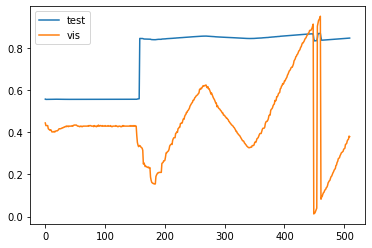

In [700]:
fig,ax = plt.subplots()
ax.plot(range(len(b)),list(b),label='test')

#ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
#ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

#ax.plot(range(len(lka[-len(b):])),lka[-len(b):],label='lka')
ax.plot(range(len(vis[-len(b):])),vis[-len(b):],label='vis')

#ax.plot(range(len(lka[:910])),lka[:910],label='lka')
#ax.plot(range(len(vis[:910])),vis[:910],label='vis')

#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [687]:
path = 'Models/publication/ae/bins/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

  0%|          | 5/2326 [00:00<00:47, 48.81it/s]

testing...


 24%|██▍       | 6/25 [00:00<00:00, 55.63it/s]6it/s]

testing...


  0%|          | 5/1224 [00:00<00:26, 46.30it/s]

...

  0%|          | 2/1224 [00:00<01:01, 19.80it/s]

testing...


 53%|█████▎    | 644/1224 [00:10<00:09, 59.49it/s]

fake


100%|█████████▉| 1221/1224 [00:19<00:00, 61.52it/s]

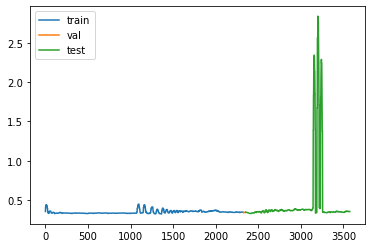

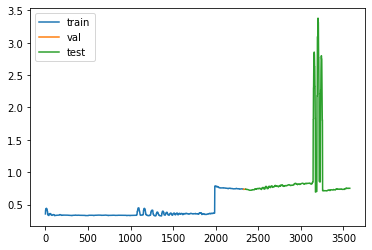

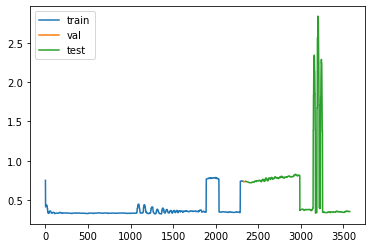

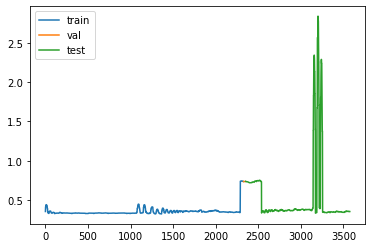

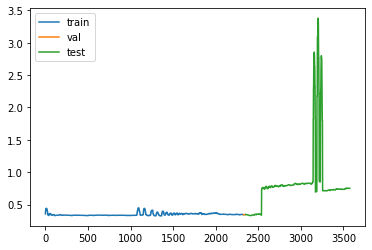

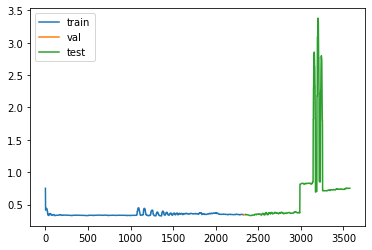

In [43]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.5 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/ae/bins/{i}/'
    #fig.savefig(f'{path}i.png')
    #save(path,[a,b,c],names=['normal','attack','train'])

In [70]:
m =  unet_seq(bs,seq_len).cuda()

In [71]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [72]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [73]:
m.lka = torch.zeros_like(m.lka).cuda()

In [74]:
loss = custom()

In [75]:
#path = 'documentation/lka/AE without variance/1/'
#cbs.load_all(path,model = m,learn=learn,opt=opt )

In [76]:
m.max_count = len(trn_dl)+len(v4_val_dl)
learn.fit(m , opt , 2 , dl,loss  ,callbacks=[sched])

  0%|          | 28/6377 [00:00<00:23, 272.17it/s, loss : 0.7474773951939174]

teet
in
[382, 673, 535, 2150, 2021, 4362, 5062]


                                               it/s, loss : 0.6208491480068897]

train Loss:  0.6205152273178101   validation loss:  0.4899670481681824
tensor(nan)


in
[560, 535, 787, 2105, 2356, 4244, 5191, 5019, 5099]


train Loss:  0.6359190344810486   validation loss:  0.4470081329345703
tensor(nan)


In [52]:
m.lka =torch.zeros(1).cuda()
m.vis_values = []
m.c =0
m.max_count = len(trn_dl)+len(v4_val_dl)+len(v4_anml_dl)
m.lka_values = []

In [53]:
trn_item.evaluate(model = m , crit = loss)

testing...


 99%|█████████▉| 6341/6377 [00:05<00:00, 1237.97it/s]

In [54]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

testing...


  0%|          | 0/3576 [00:00<?, ?it/s]

testing...


 99%|█████████▊| 3529/3576 [00:03<00:00, 1244.14it/s]

In [55]:
lka = [i[0][0] for i in m.lka_values]
vis = [i[0][1] for i in m.lka_values]
#diff = [i[0][3] for i in m.lka_values]
op = [i[1][0] for i in m.lka_values]

IndexError: invalid index of a 0-dim tensor. Use tensor.item() to convert a 0-dim tensor to a Python number

Dis:It consider normal flow data as anomaly.

In [ ]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
#ax.plot(range(len(diff)),diff)
#ax.plot(range(len(op)),op)


threshold = b[:100].max()
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))
ax.plot(range(len(c),len(c)+len(a)),list(a))
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b))
#ax.plot(range(len(lka)),lka)
ax.plot(range(len(a)+len(b)+len(c)), [threshold]*(len(a)+len(b)+len(c)))

fig,ax = plt.subplots()
ax.plot(range(len(vis)),vis)


In [ ]:
path = 'Models/documentation/lka/AE without variance/run2/1/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

## AE Simplified

In [30]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(1).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(2,2),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(2,4),
                                            nn.PReLU(),
                                            nn.Dropout(0.5),
                                            nn.Linear(4,2),
                                            nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros_like(self.lka)
        self.previous_vis = torch.rand_like(self.vis)
        
        self.previous_states = torch.zeros(1).cuda()
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c = 0
        
        self.vis_values = []
        self.vis_idx = []
        
        self.lka_values = []
        self.max_count = 2352
        
        self.diff_avg = []
        #list of artficial lka 
        self.art_lka =[]
        #Random normal
        self.m = normal.Normal(0.5244,0.0051)
    def forward(self,x):   
        self.c = (self.c+1) % self.max_count
        input_list = x.view(80,-1).cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            frame = x.view(80,-1)[vis_idx[0]][120:208]
            _,vis_value = get_vis(frame[28:28+16].data)
            self.vis = vis_value.cuda()
            #Storage for analysis
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        
        if self.c == self.max_count:
            self.lka = torch.zeros(1).cuda()
        
        if self.c == 1 :
            self.vis_values = []
            self.art_lka =[]
            print('in')
            idx = random.randint(0,3)
            if idx  != 0:
                self.art_lka = torch.randint(250,600,(1,idx*2)).tolist()[0]
            print(self.art_lka)
            
          
        if self.c in [1000,1300]:
            #[1000,1300]
            #[2400]
            #[10,20,30,2400]
            #[20,30,50,2400]
        #lka_idx.size or self.c in self.art_lka :
            
            #[0,20,30,35,45,48,50,60,68,70,75,80,95,100,150,180,230,250,300,320,333,350,390,400,480]
            if self.lka[0]:
                print('LKA OFF',self.c)
                self.lka = torch.zeros(1).cuda()
            else:
                print('LKA ON',self.c)
                self.lka = torch.ones(1).cuda()
        
        
        cat=torch.cat([self.previous_lka,(normalize(self.vis)+self.m.sample())/2,])#.cuda()
        
        predected_lka = self.lka_compressor(cat)
        
        self.previous_vis = self.vis.data.detach()
        self.previous_lka = self.lka.data.detach()
        
        self.lka_values.append([cat,predected_lka.data])
        
        return cat,predected_lka


In [31]:
m =  unet_seq(bs,seq_len).cuda()

In [32]:
opt = torch.optim.Adam(m.parameters(),1e-8)
opt = BaseOptimizer(opt)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt.opt,(len(trn_dl)+len(v4_val_dl)))
sched = scheduler(sched)
learn = learner()

In [33]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [34]:
m.lka = torch.zeros_like(m.lka).cuda()

In [35]:
loss = SSIM()

In [36]:
path = 'documentation/lka/AE without variance/simplified/1/'
#cbs.load_all(path,model = m,learn=learn,opt=opt )

In [37]:
#m.max_count = len(trn_dl)+len(v4_val_dl)
#learn.fit(m , opt , 2 , dl,loss  ,callbacks=[sched])

In [38]:
m.lka =torch.zeros(1).cuda()
m.vis_values = []
m.c =0
m.max_count = len(trn_dl)+len(v4_val_dl)+len(v4_anml_dl)
m.lka_values = []

In [39]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 1/2326 [00:00<07:07,  5.44it/s]

testing...
in
[498, 332, 366, 336]


 43%|████▎     | 1004/2326 [00:18<00:49, 26.46it/s]

LKA ON 1000


 56%|█████▌    | 1302/2326 [00:23<00:25, 40.07it/s]

LKA OFF 1300


100%|██████████| 2326/2326 [00:41<00:00, 40.55it/s]

In [40]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

 28%|██▊       | 7/25 [00:00<00:00, 67.98it/s]

testing...


  0%|          | 1/1224 [00:00<02:07,  9.57it/s]

testing...


100%|█████████▉| 1218/1224 [00:21<00:00, 27.77it/s]

In [41]:
lka = [i[0][0] for i in m.lka_values]
vis = [i[0][1] for i in m.lka_values]
#diff = [i[0][3] for i in m.lka_values]
op = [i[1][0] for i in m.lka_values]

Dis:It consider normal flow data as anomaly.

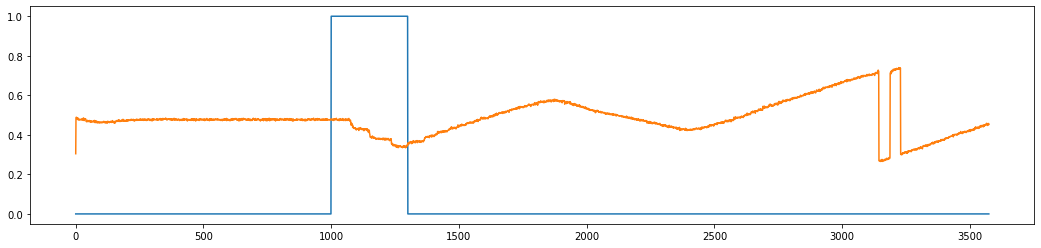

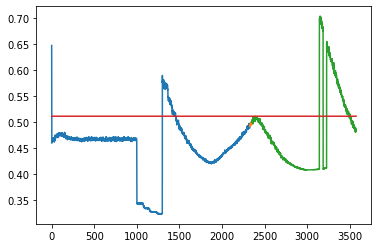

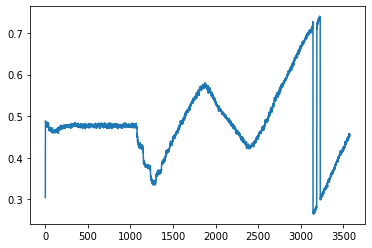

In [42]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(lka)),lka)
ax.plot(range(len(vis)),vis)
#ax.plot(range(len(diff)),diff)
#ax.plot(range(len(op)),op)


threshold = b[:100].max()
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))
ax.plot(range(len(c),len(c)+len(a)),list(a))
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b))
#ax.plot(range(len(lka)),lka)
ax.plot(range(len(a)+len(b)+len(c)), [threshold]*(len(a)+len(b)+len(c)))

fig,ax = plt.subplots()
ax.plot(range(len(vis)),vis)


In [43]:
path = 'Models/documentation/lka/AE without variance/simplified/1/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

In [47]:
torch.tensor(vis[2500:3000]).std()

tensor(0.0630)

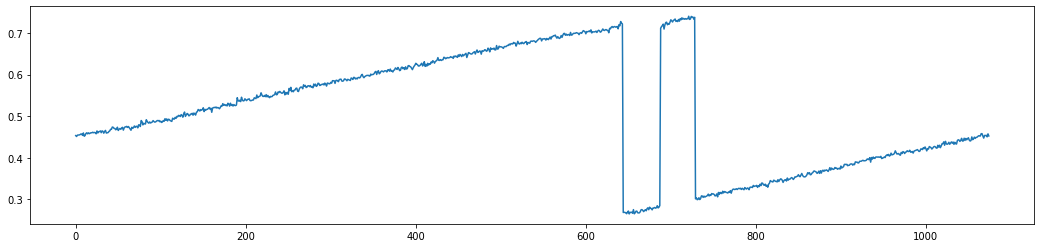

In [46]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(range(len(vis[2500:])),vis[2500:])